# Pulse Indexer Model (PIM) Example

The Pulse Indexer Model (PIM) predicts the index of cardiac pressure waveform fiducial points for the inflection and dicrotic notch. The model takes a single cardiac cycle in the form of a numpy array as input and outputs a numpy array with the indices corresponding to the fiducial point locations. 

The ```PimPredictor``` class provices an interface for predicting using a pretrained instance of the model. Currently, two instance of the pretrained model can be used as initialization checkpoints (```'base_model.pth'``` or ```'augmented_model.pth'```). To prompt the model, using the ```.predict``` functionality and pass the waveform and the ```dt``` between successive timepoints in milliseconds. 

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [47]:
def show_fiducial_points(wvf, output):
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(wvf, label='waveform', color='black')
    ax.scatter(output[0], wvf[output[0]], marker='o', color='tab:green', label=r'$t_i$', zorder=10)
    ax.scatter(output[1], wvf[output[1]], marker='o', color='tab:blue', label=r'$t_n$', zorder=10)
    ax.legend(fontsize=10)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Pressure (mmHg)')
    plt.tight_layout()
    plt.show()


In [6]:
# Setting up the model
import sys
sys.path.append('../src')
from pulse_indexer import PimPredictor
checkpoint = 'augmented_model.pth'
pim = PimPredictor(checkpoint=checkpoint)

Output:  [274 335]


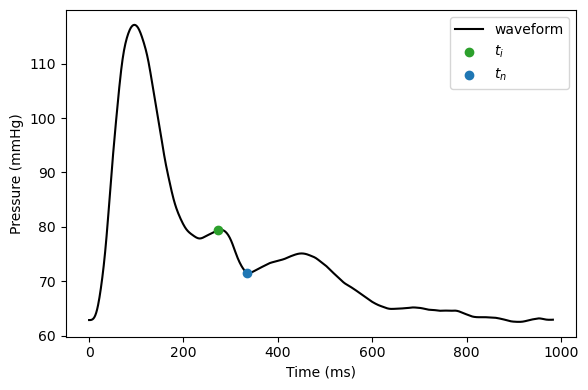

In [52]:
# predicting a waveform fiducial points
idx = 5
wvf = np.load(f'./signals/waveform_{idx}.npy')
output = pim.predict(wvf)
print('Output: ', output)
show_fiducial_points(wvf, output)